# Calories Burned Prediction

## Project Introduction

The goal of this project is to analyze gym workout data and investigate which personal and workout-related factors are most strongly related to calories burned.

The final objective is to build a regression model that predicts calories burned during a workout.

## Dataset Overview

The dataset contains information about gym members, including age, gender, weight, height, heart rate, workout duration, workout type, experience level, and calories burned.

The target variable is `Calories_Burned`.

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('../data/raw/gym_members_exercise_tracking.csv')
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


## Data Quality Check

In this section, the dataset is checked for missing values, duplicate rows, and incorrect data types.

In [4]:
print('number of columns and rows:')
print(df.shape)

number of columns and rows:
(973, 15)


In [5]:
print('column names:')
print(df.columns.tolist())

column names:
['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI']


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    str    
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    str    
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int64  
 13  E

In [7]:
print("Missing values per column:")
print(df.isna().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

Missing values per column:
Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64

Number of duplicate rows:
0


In [9]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].value_counts())


Gender:
Gender
Male      511
Female    462
Name: count, dtype: int64

Workout_Type:
Workout_Type
Strength    258
Cardio      255
Yoga        239
HIIT        221
Name: count, dtype: int64


/var/folders/4w/hptgzhfj11vc643tzb3gjdk00000gn/T/ipykernel_54423/1365264059.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


In [10]:
numeric_data= df.select_dtypes(include='number')

In [11]:
print(numeric_data)

     Age  Weight (kg)  Height (m)  Max_BPM  Avg_BPM  Resting_BPM  \
0     56         88.3        1.71      180      157           60   
1     46         74.9        1.53      179      151           66   
2     32         68.1        1.66      167      122           54   
3     25         53.2        1.70      190      164           56   
4     38         46.1        1.79      188      158           68   
..   ...          ...         ...      ...      ...          ...   
968   24         87.1        1.74      187      158           67   
969   25         66.6        1.61      184      166           56   
970   59         60.4        1.76      194      120           53   
971   32        126.4        1.83      198      146           62   
972   46         88.7        1.63      166      146           66   

     Session_Duration (hours)  Calories_Burned  Fat_Percentage  \
0                        1.69           1313.0            12.6   
1                        1.30            883.0     

In [12]:
correlation_table= numeric_data.corr()
print(correlation_table)

                                    Age  Weight (kg)  Height (m)   Max_BPM  \
Age                            1.000000    -0.036340   -0.027837 -0.017073   
Weight (kg)                   -0.036340     1.000000    0.365321  0.057061   
Height (m)                    -0.027837     0.365321    1.000000 -0.017660   
Max_BPM                       -0.017073     0.057061   -0.017660  1.000000   
Avg_BPM                        0.035969     0.009717   -0.014776 -0.039751   
Resting_BPM                    0.004354    -0.032138   -0.005090  0.036647   
Session_Duration (hours)      -0.019912    -0.013666   -0.010206  0.010051   
Calories_Burned               -0.154679     0.095443    0.086348  0.002090   
Fat_Percentage                 0.002370    -0.225512   -0.235521 -0.009056   
Water_Intake (liters)          0.041528     0.394276    0.393533  0.031621   
Workout_Frequency (days/week)  0.008055    -0.011769   -0.011270 -0.029099   
Experience_Level              -0.018676     0.003379   -0.010267

In [13]:
calorie_correlation = correlation_table['Calories_Burned']

print(calorie_correlation)

Age                             -0.154679
Weight (kg)                      0.095443
Height (m)                       0.086348
Max_BPM                          0.002090
Avg_BPM                          0.339659
Resting_BPM                      0.016518
Session_Duration (hours)         0.908140
Calories_Burned                  1.000000
Fat_Percentage                  -0.597615
Water_Intake (liters)            0.356931
Workout_Frequency (days/week)    0.576150
Experience_Level                 0.694129
BMI                              0.059761
Name: Calories_Burned, dtype: float64


## Exploratory Data Analysis

This section investigates the relationships between workout characteristics and calories burned.

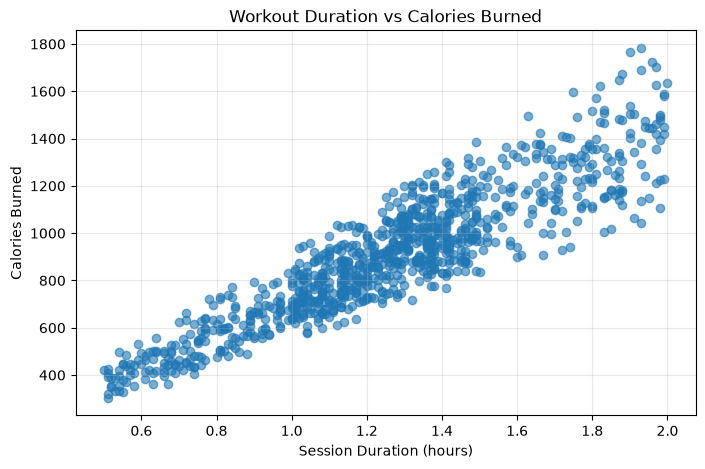

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Session_Duration (hours)"],
    df["Calories_Burned"],
    alpha=0.6
)

plt.title("Workout Duration vs Calories Burned")
plt.xlabel("Session Duration (hours)")
plt.ylabel("Calories Burned")
plt.grid(alpha=0.3)


plt.show()


Average Calories Burned by Gender:
Gender
Male      944.455969
Female    862.248918
Name: Calories_Burned, dtype: float64


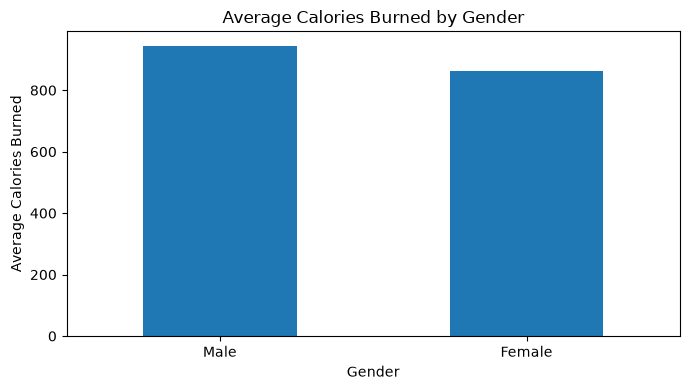


Average Calories Burned by Workout_Type:
Workout_Type
HIIT        925.805430
Strength    910.697674
Yoga        903.188285
Cardio      884.513725
Name: Calories_Burned, dtype: float64


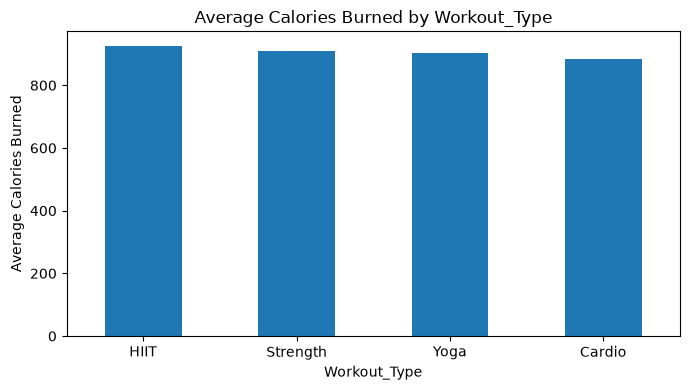

In [19]:
categorical_columns = df.select_dtypes(
    include=["object", "string"]
).columns

for column in categorical_columns:

    average_calories = (
        df.groupby(column)["Calories_Burned"]
        .mean()
        .sort_values(ascending=False)
    )

    print(f"\nAverage Calories Burned by {column}:")
    print(average_calories)

    average_calories.plot(
        kind="bar",
        figsize=(7, 4)
    )

    plt.title(f"Average Calories Burned by {column}")
    plt.xlabel(column)
    plt.ylabel("Average Calories Burned")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

## Categorical Features and Calories Burned

The categorical features `Gender` and `Workout_Type` were analyzed by comparing the average `Calories_Burned` for each category.

I used `groupby()` and `mean()` to calculate the average calories burned for each group, and bar charts were used to visualize the results.

For `Workout_Type`, HIIT had the highest average calories burned, followed by Strength, Yoga, and Cardio.

The same method was used to compare the average calories burned between Male and Female participants.


### Average Calories Burned by Experience Level

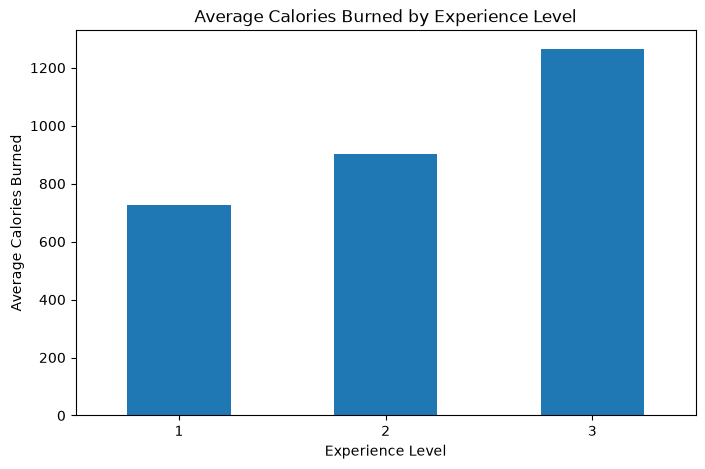

In [17]:
average_calories_by_experience = (
    df.groupby("Experience_Level")["Calories_Burned"]
    .mean()
    .sort_index()
)

average_calories_by_experience.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Calories Burned by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Average Calories Burned")
plt.xticks(rotation=0)


plt.show()

### Finding

Average calories burned increase clearly with experience level. Level 3 members burn substantially more calories than Level 1 and Level 2 members.

However, this result may also be influenced by other factors, such as workout duration and workout frequency.

### Correlation with Calories Burned

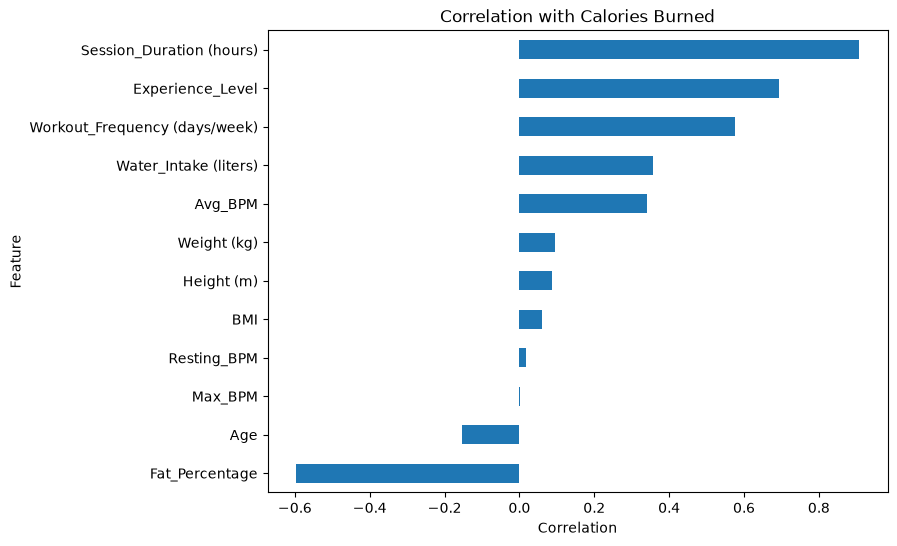

In [20]:
numeric_data = df.select_dtypes(include="number")

calorie_correlations = (
    numeric_data.corr()["Calories_Burned"]
    .drop("Calories_Burned")
    .sort_values()
)

plt.figure(figsize=(8, 6))

calorie_correlations.plot(kind="barh")

plt.title("Correlation with Calories Burned")
plt.xlabel("Correlation")
plt.ylabel("Feature")


plt.show()

### Finding

Session duration has the strongest positive relationship with calories burned.

Experience level and workout frequency also show clear positive relationships, while body fat percentage has a moderate negative relationship with calories burned.

These results suggest that session duration should be an important feature in the prediction model.

## Key Findings

- Session duration has the strongest positive relationship with calories burned.
- Experience level and workout frequency are also positively related to calories burned.
- Body fat percentage shows a moderate negative relationship with calories burned.
- HIIT has the highest average calorie expenditure, but the differences between workout types are relatively small.

